# Exploratory Data Analysis (EDA)
## Chronic Kidney Disease Dataset

This notebook explores the cleaned CKD dataset to understand:

- Feature distributions
- Differences between CKD and non-CKD patients
- Relationships between clinical indicators
- Potential predictors of chronic kidney disease

The goal of this analysis is to identify patterns in the data before building predictive models.

In [1]:
# ============================================================
# Import libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ============================================================
# Load cleaned dataset
# ============================================================

FILE_PATH = "/content/ckd_cleaned.csv"

df = pd.read_csv(FILE_PATH)

print("Dataset loaded.")
print("Shape:", df.shape)

df.head()

Dataset loaded.
Shape: (200, 27)


,bp_diastolic,bp limit,sg,al,class,rbc,su,pc,pcc,ba,...,rbcc,wbcc,htn,dm,cad,appet,pe,ane,grf,age
0,0.0,0.0,1.020,1.0,1,0.0,0.0,0.0,0.0,0.0,...,4.755,8550.0,0.0,0.0,0.0,0.0,0.0,0.0,227.944,12.0
1,0.0,0.0,1.010,0.0,1,0.0,0.0,0.0,0.0,0.0,...,4.755,13310.0,0.0,0.0,0.0,0.0,0.0,0.0,227.944,12.0
2,0.0,0.0,1.010,4.0,1,1.0,0.0,1.0,0.0,1.0,...,4.755,15690.0,0.0,0.0,0.0,1.0,0.0,0.0,139.8635,12.0
3,1.0,1.0,1.010,3.0,1,0.0,0.0,0.0,0.0,0.0,...,4.755,8550.0,0.0,0.0,0.0,0.0,0.0,0.0,139.8635,12.0
4,0.0,0.0,1.016,0.0,1,0.0,0.0,0.0,0.0,0.0,...,5.345,8550.0,0.0,1.0,0.0,1.0,1.0,0.0,139.8635,16.0


In [10]:
df["grf"] = pd.to_numeric(df["grf"], errors="coerce")

print("grf column converted to numeric.")
print(df["grf"].dtype)

grf column converted to numeric.
float64


## Dataset Overview

We begin by examining the structure of the cleaned dataset including feature names and data types.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   bp_diastolic  200 non-null    float64
 1   bp limit      200 non-null    float64
 2   sg            200 non-null    float64
 3   al            200 non-null    float64
 4   class         200 non-null    int64  
 5   rbc           200 non-null    float64
 6   su            200 non-null    float64
 7   pc            200 non-null    float64
 8   pcc           200 non-null    float64
 9   ba            200 non-null    float64
 10  bgr           200 non-null    float64
 11  bu            200 non-null    float64
 12  sod           200 non-null    float64
 13  sc            200 non-null    float64
 14  pot           200 non-null    float64
 15  hemo          200 non-null    float64
 16  pcv           200 non-null    float64
 17  rbcc          200 non-null    float64
 18  wbcc          200 non-null    

## CKD vs Non-CKD Distribution

Understanding the class distribution helps determine whether the dataset is balanced.

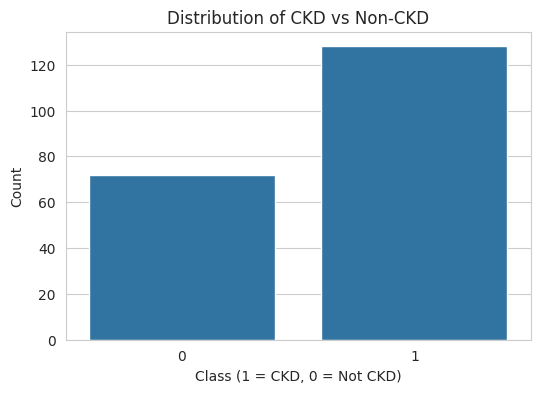

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(x="class", data=df)

plt.title("Distribution of CKD vs Non-CKD")
plt.xlabel("Class (1 = CKD, 0 = Not CKD)")
plt.ylabel("Count")

plt.show()

## Example Feature Distribution: Hemoglobin

Hemoglobin levels are an important indicator of kidney function.  
We examine how hemoglobin values are distributed across patients.

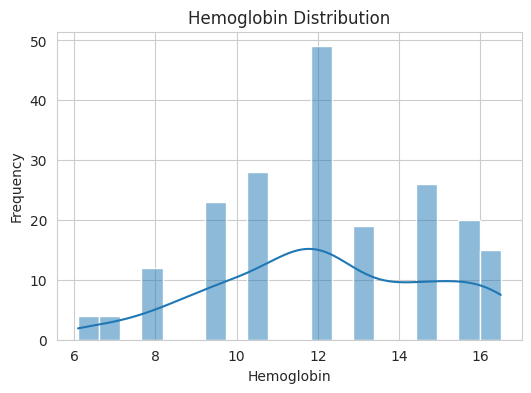

In [5]:
plt.figure(figsize=(6,4))

sns.histplot(df["hemo"], bins=20, kde=True)

plt.title("Hemoglobin Distribution")
plt.xlabel("Hemoglobin")
plt.ylabel("Frequency")

plt.show()

## Hemoglobin by CKD Status

This visualization compares hemoglobin levels between CKD and non-CKD patients.

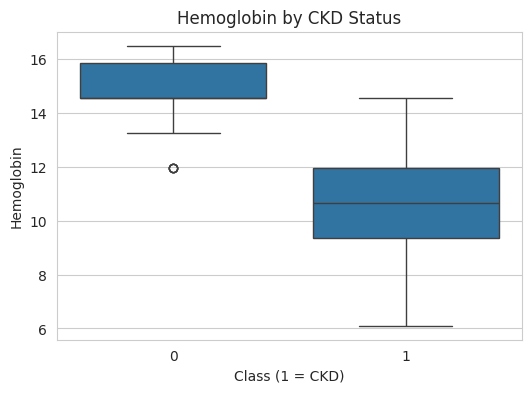

In [6]:
plt.figure(figsize=(6,4))

sns.boxplot(x="class", y="hemo", data=df)

plt.title("Hemoglobin by CKD Status")
plt.xlabel("Class (1 = CKD)")
plt.ylabel("Hemoglobin")

plt.show()

## Feature Correlation Heatmap

Correlation analysis helps identify relationships between clinical measurements and CKD status.

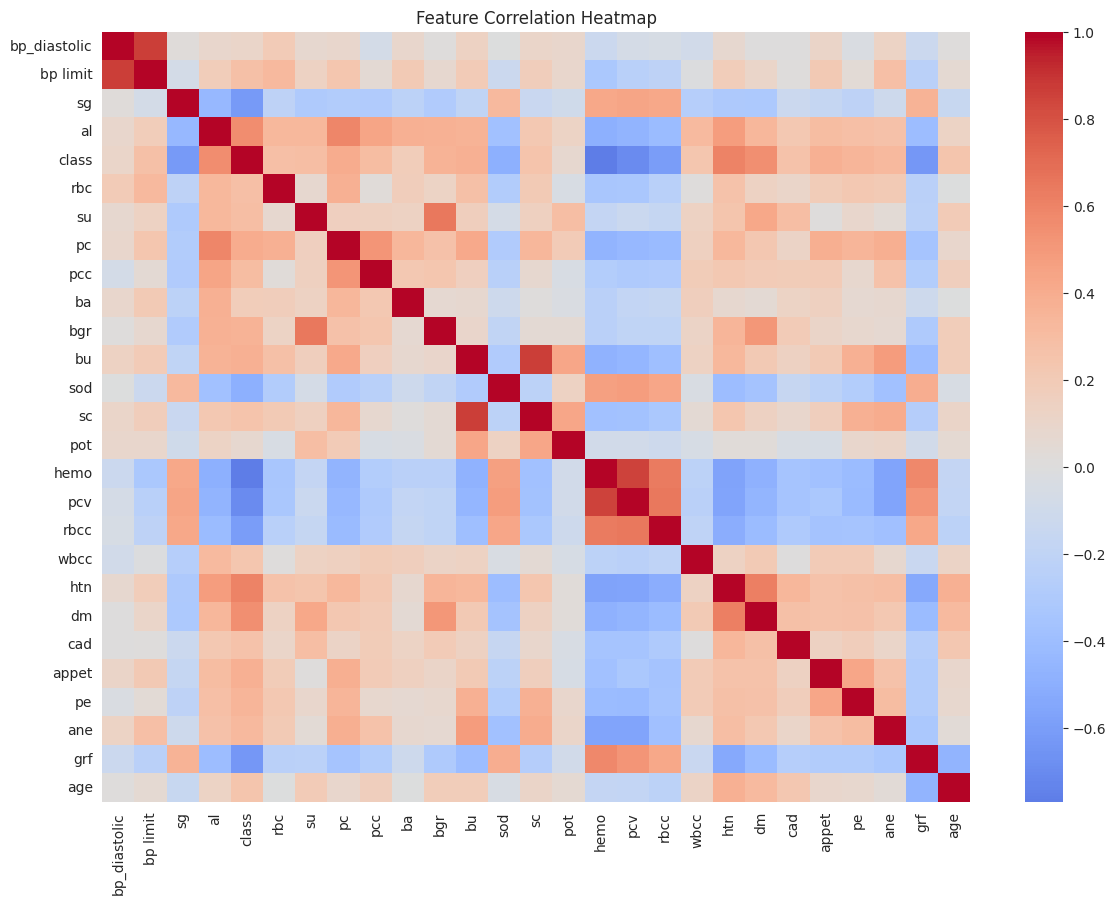

In [11]:
plt.figure(figsize=(14, 10))

numeric_df = df.select_dtypes(include=["number"])
corr = numeric_df.corr()

sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Feature Correlation Heatmap")
plt.show()

In [9]:
non_numeric_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

print("Non-numeric columns:")
print(non_numeric_cols)

for col in non_numeric_cols:
    print(f"\nColumn: {col}")
    print(df[col].dropna().astype(str).unique()[:10])

Non-numeric columns:
['grf']

Column: grf
['227.944' '139.8635' '114.69800000000001' '190.195' '39.20035' '64.3661'
 '89.532' '165.029' '215.361' '26.6175']


## Features Most Associated with CKD

To identify the clinical measurements most associated with CKD, we examine the correlation between each feature and the target variable (`class`).

Higher absolute correlation values indicate stronger relationships with CKD status.

In [12]:
# ============================================================
# Correlation with target variable
# ============================================================

corr_matrix = df.corr()

ckd_corr = corr_matrix["class"].drop("class")

ckd_corr_sorted = ckd_corr.sort_values(ascending=False)

ckd_corr_sorted

,class
htn,0.599693
al,0.554090
dm,0.550350
pc,0.404112
appet,0.375000
bu,0.371689
bgr,0.358284
pe,0.345425
ane,0.327327
pcc,0.296292


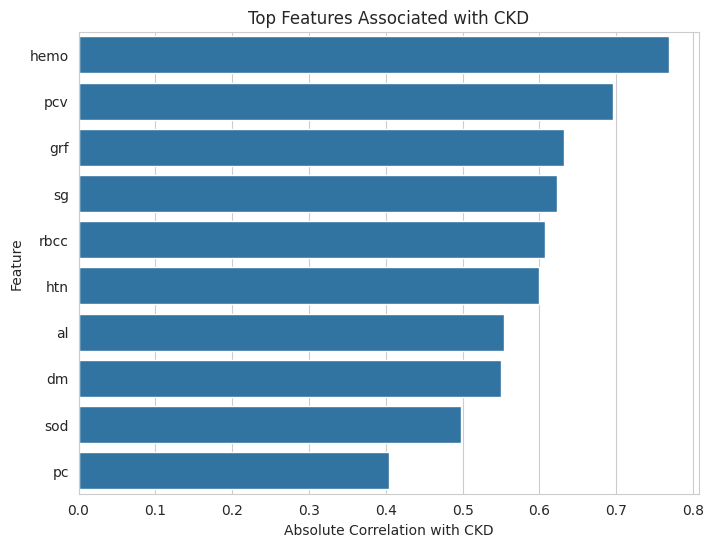

In [13]:
top_features = ckd_corr_sorted.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))

sns.barplot(x=top_features.values, y=top_features.index)

plt.title("Top Features Associated with CKD")
plt.xlabel("Absolute Correlation with CKD")
plt.ylabel("Feature")

plt.show()

### Key Observations

Several laboratory measurements show strong associations with CKD.

Hemoglobin (`hemo`) and packed cell volume (`pcv`) show the strongest negative correlations, indicating that patients with CKD tend to have lower values for these blood indicators.

Estimated glomerular filtration rate (`grf`) also shows a strong negative correlation with CKD, which is expected because declining kidney function reduces filtration capacity.

Among categorical predictors, hypertension (`htn`) and diabetes (`dm`) show strong positive correlations with CKD, reflecting their known role as major risk factors for kidney disease.

These results suggest that the dataset captures clinically meaningful predictors of CKD.

## CKD vs Non-CKD Feature Comparisons

To further understand the strongest predictors of CKD, we compare the distributions of key laboratory indicators between CKD and non-CKD patients.

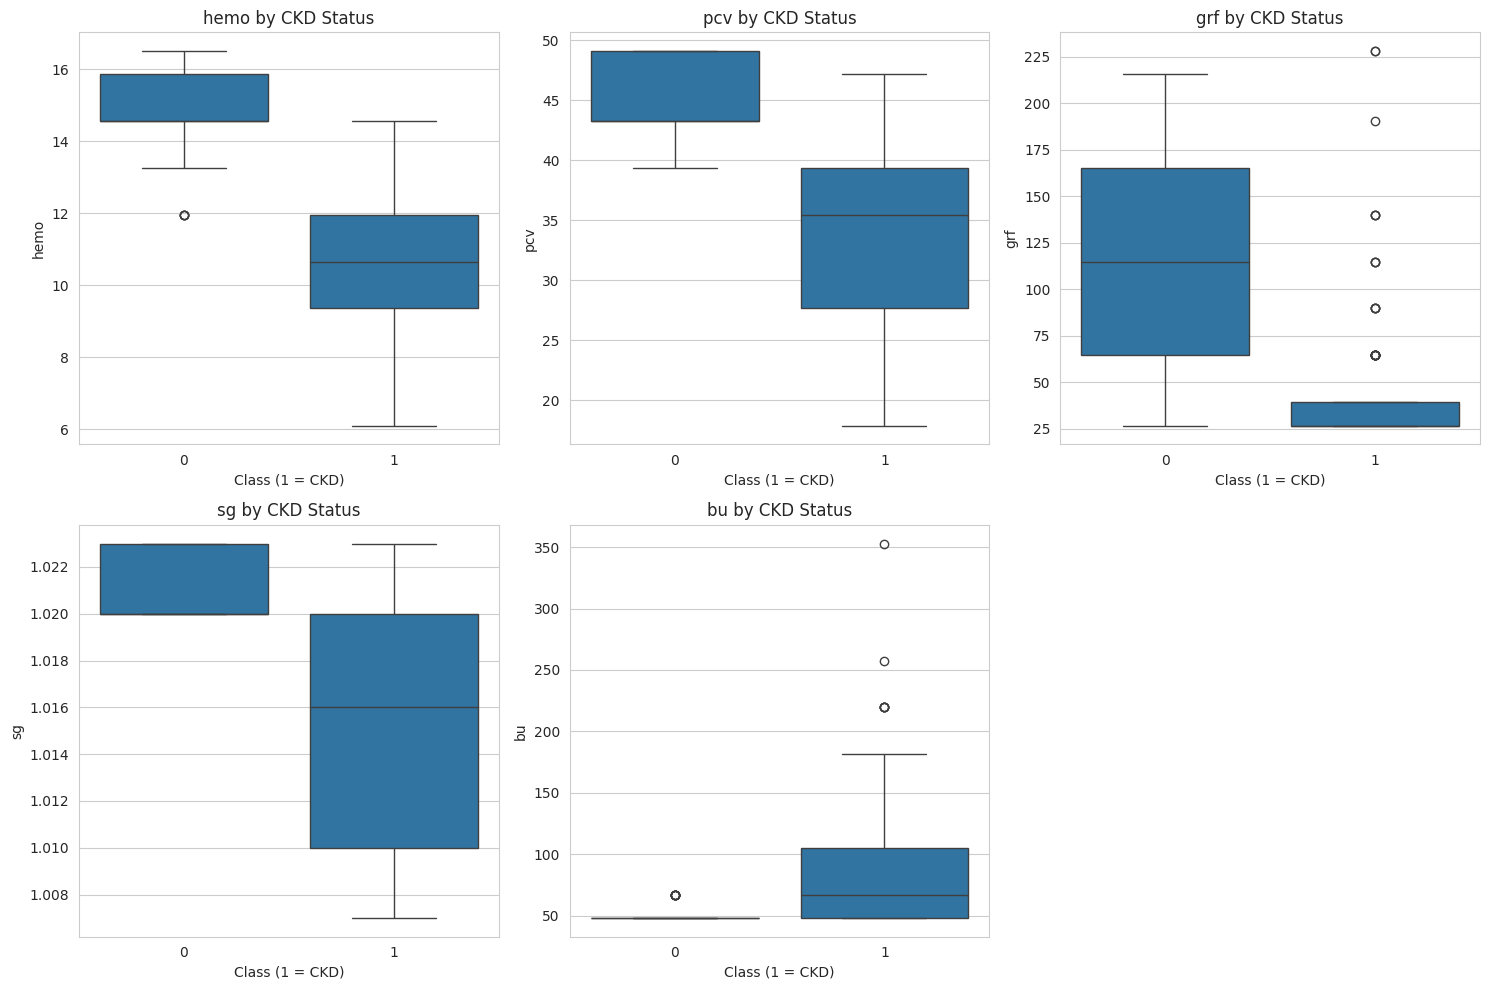

In [14]:
important_features = ["hemo", "pcv", "grf", "sg", "bu"]

plt.figure(figsize=(15,10))

for i, feature in enumerate(important_features):

    plt.subplot(2,3,i+1)

    sns.boxplot(x="class", y=feature, data=df)

    plt.title(f"{feature} by CKD Status")
    plt.xlabel("Class (1 = CKD)")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

### Interpretation of Feature Distributions

The boxplots highlight several clinically meaningful differences between CKD and non-CKD patients.

Hemoglobin (`hemo`) and packed cell volume (`pcv`) are substantially lower in CKD patients, reflecting the anemia commonly associated with impaired kidney function.

Estimated glomerular filtration rate (`grf`) shows a clear separation between groups, with CKD patients exhibiting much lower filtration rates.

Blood urea (`bu`) is elevated in CKD patients, indicating reduced ability of the kidneys to remove metabolic waste.

Specific gravity (`sg`) also differs between groups, suggesting altered urine concentration ability in CKD patients.

These patterns confirm that the dataset contains physiologically meaningful signals that can be leveraged for predictive modeling.

## Pairwise Relationships Among Key Clinical Predictors

To further explore the relationships between important clinical indicators, we visualize pairwise relationships among several key predictors.

This plot helps reveal:

- relationships between predictors
- clustering patterns between CKD and non-CKD patients
- potential separability of classes for machine learning models

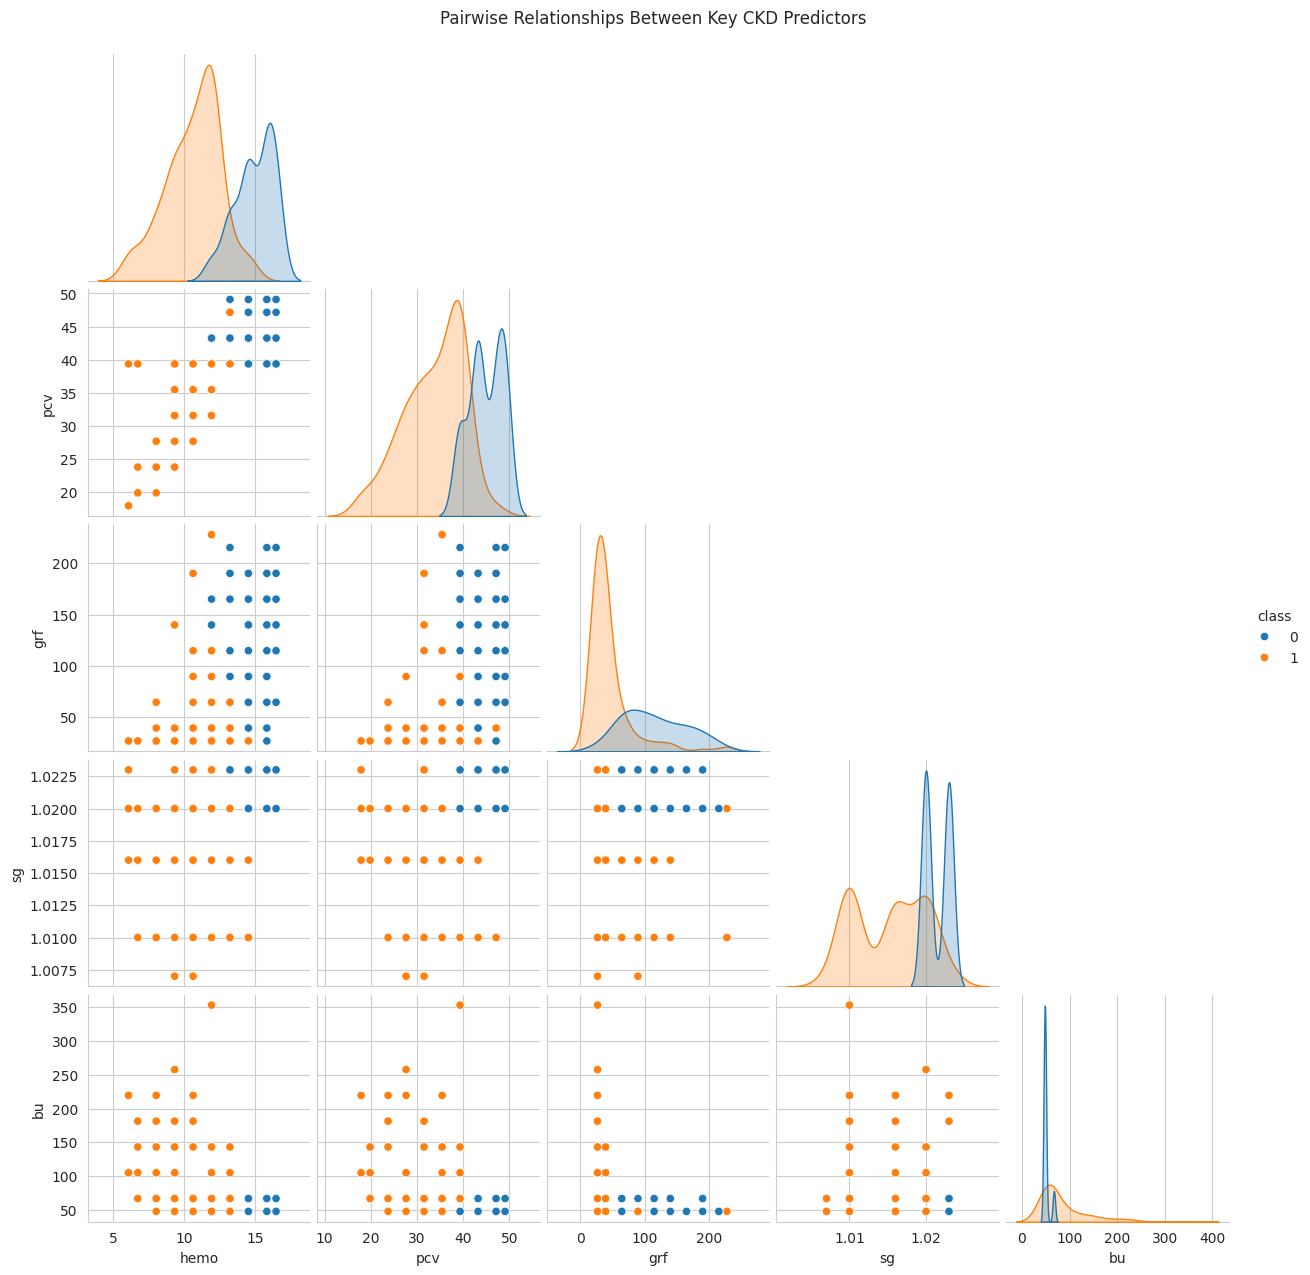

In [15]:
important_features = ["hemo", "pcv", "grf", "sg", "bu", "class"]

sns.pairplot(
    df[important_features],
    hue="class",
    diag_kind="kde",
    corner=True
)

plt.suptitle("Pairwise Relationships Between Key CKD Predictors", y=1.02)

plt.show()

### Observations

The pairplot reveals noticeable clustering differences between CKD and non-CKD patients across several predictors.

Hemoglobin (`hemo`) and packed cell volume (`pcv`) show clear separation between classes, with CKD patients tending to exhibit lower values.

Glomerular filtration rate (`grf`) also demonstrates distinct clustering, reflecting reduced kidney filtration capacity among CKD patients.

These patterns suggest that the dataset contains meaningful feature relationships that can be leveraged by predictive models.